In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load original data (for EDA we use original labels)
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


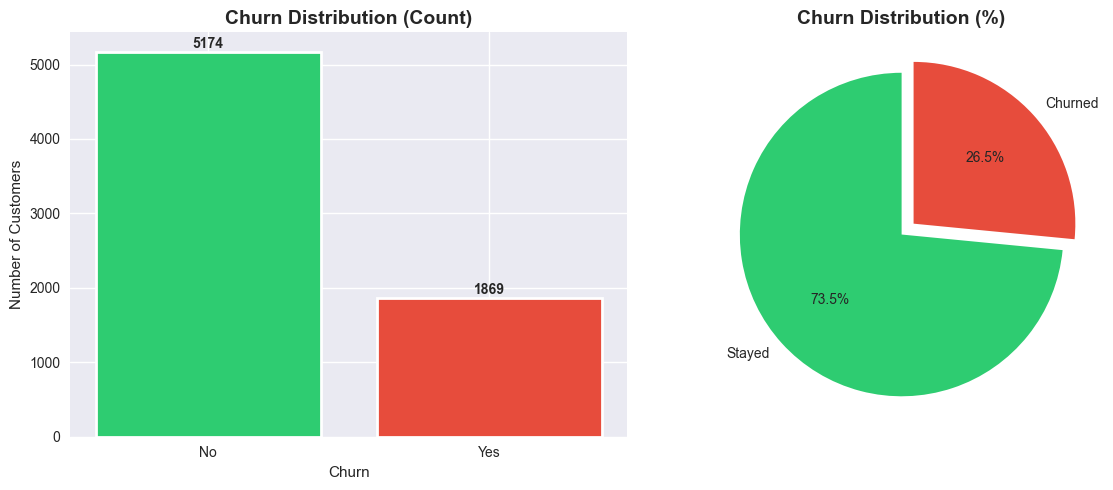

✅ Plot saved!


In [3]:
# PLOT 1: Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, 
            labels=['Stayed', 'Churned'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../src/images/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

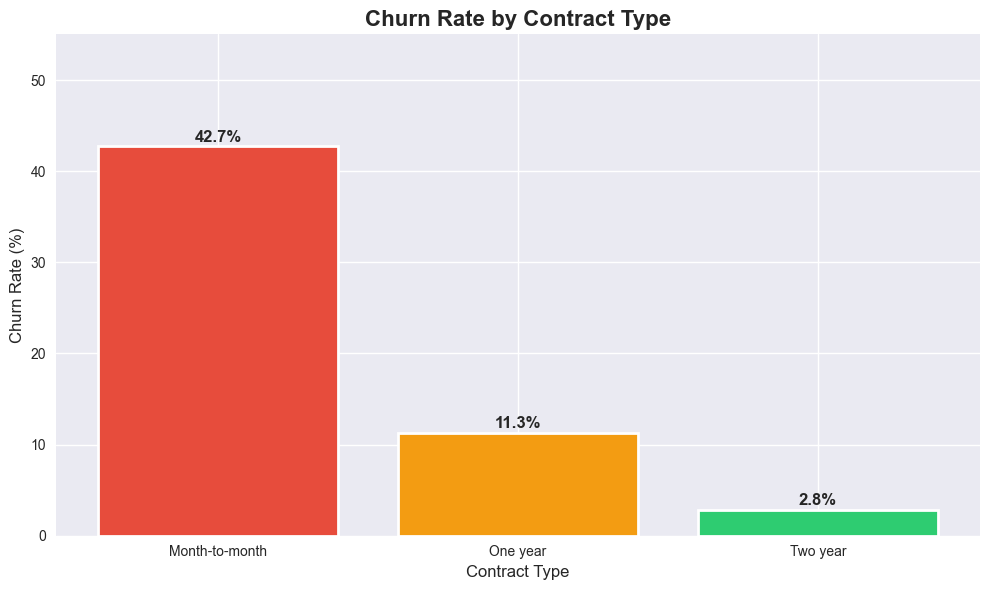

✅ Plot saved!


In [4]:
# PLOT 2: Churn by Contract Type
fig, ax = plt.subplots(figsize=(10, 6))

contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
              color=['#e74c3c', '#f39c12', '#2ecc71'], 
              edgecolor='white', linewidth=2)

ax.set_title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 55)

for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../src/images/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

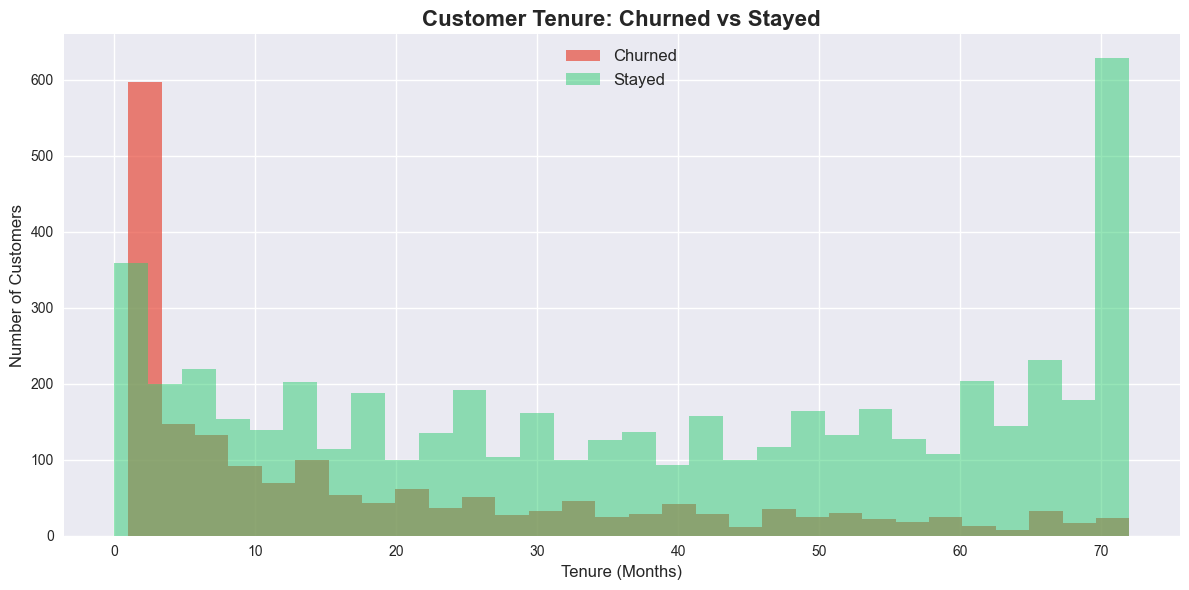

✅ Plot saved!


In [5]:
# PLOT 3: Churn by Tenure
fig, ax = plt.subplots(figsize=(12, 6))

df[df['Churn'] == 'Yes']['tenure'].hist(
    bins=30, alpha=0.7, label='Churned', color='#e74c3c', ax=ax)
df[df['Churn'] == 'No']['tenure'].hist(
    bins=30, alpha=0.5, label='Stayed', color='#2ecc71', ax=ax)

ax.set_title('Customer Tenure: Churned vs Stayed', fontsize=16, fontweight='bold')
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../src/images/03_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

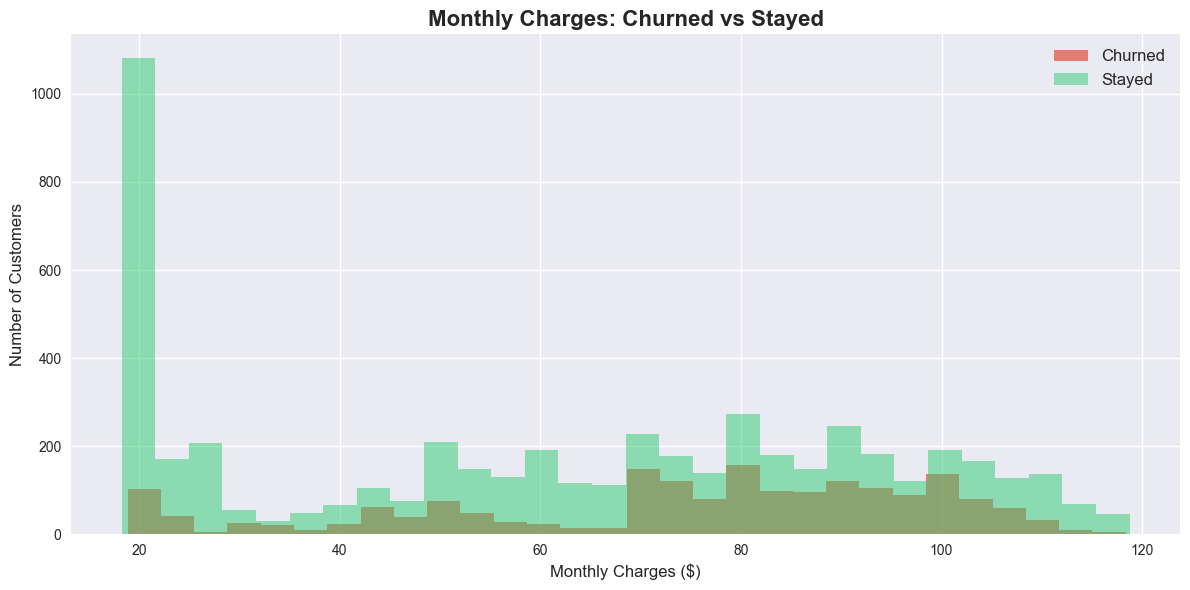

✅ Plot saved!


In [6]:
# PLOT 4: Monthly Charges Distribution
fig, ax = plt.subplots(figsize=(12, 6))

df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, label='Churned', color='#e74c3c', ax=ax)
df[df['Churn'] == 'No']['MonthlyCharges'].hist(
    bins=30, alpha=0.5, label='Stayed', color='#2ecc71', ax=ax)

ax.set_title('Monthly Charges: Churned vs Stayed', fontsize=16, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../src/images/04_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

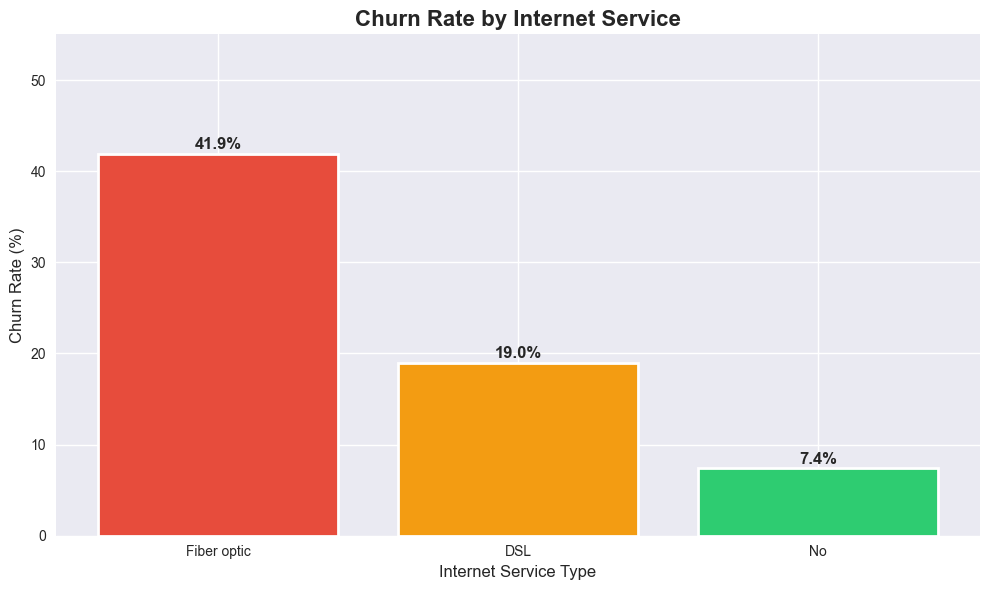

✅ Plot saved!


In [7]:
# PLOT 5: Churn by Internet Service
fig, ax = plt.subplots(figsize=(10, 6))

internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
internet_churn.columns = ['InternetService', 'Churn Rate (%)']
internet_churn = internet_churn.sort_values('Churn Rate (%)', ascending=False)

bars = ax.bar(internet_churn['InternetService'], internet_churn['Churn Rate (%)'],
              color=['#e74c3c', '#f39c12', '#2ecc71'],
              edgecolor='white', linewidth=2)

ax.set_title('Churn Rate by Internet Service', fontsize=16, fontweight='bold')
ax.set_xlabel('Internet Service Type', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 55)

for bar, val in zip(bars, internet_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../src/images/05_churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

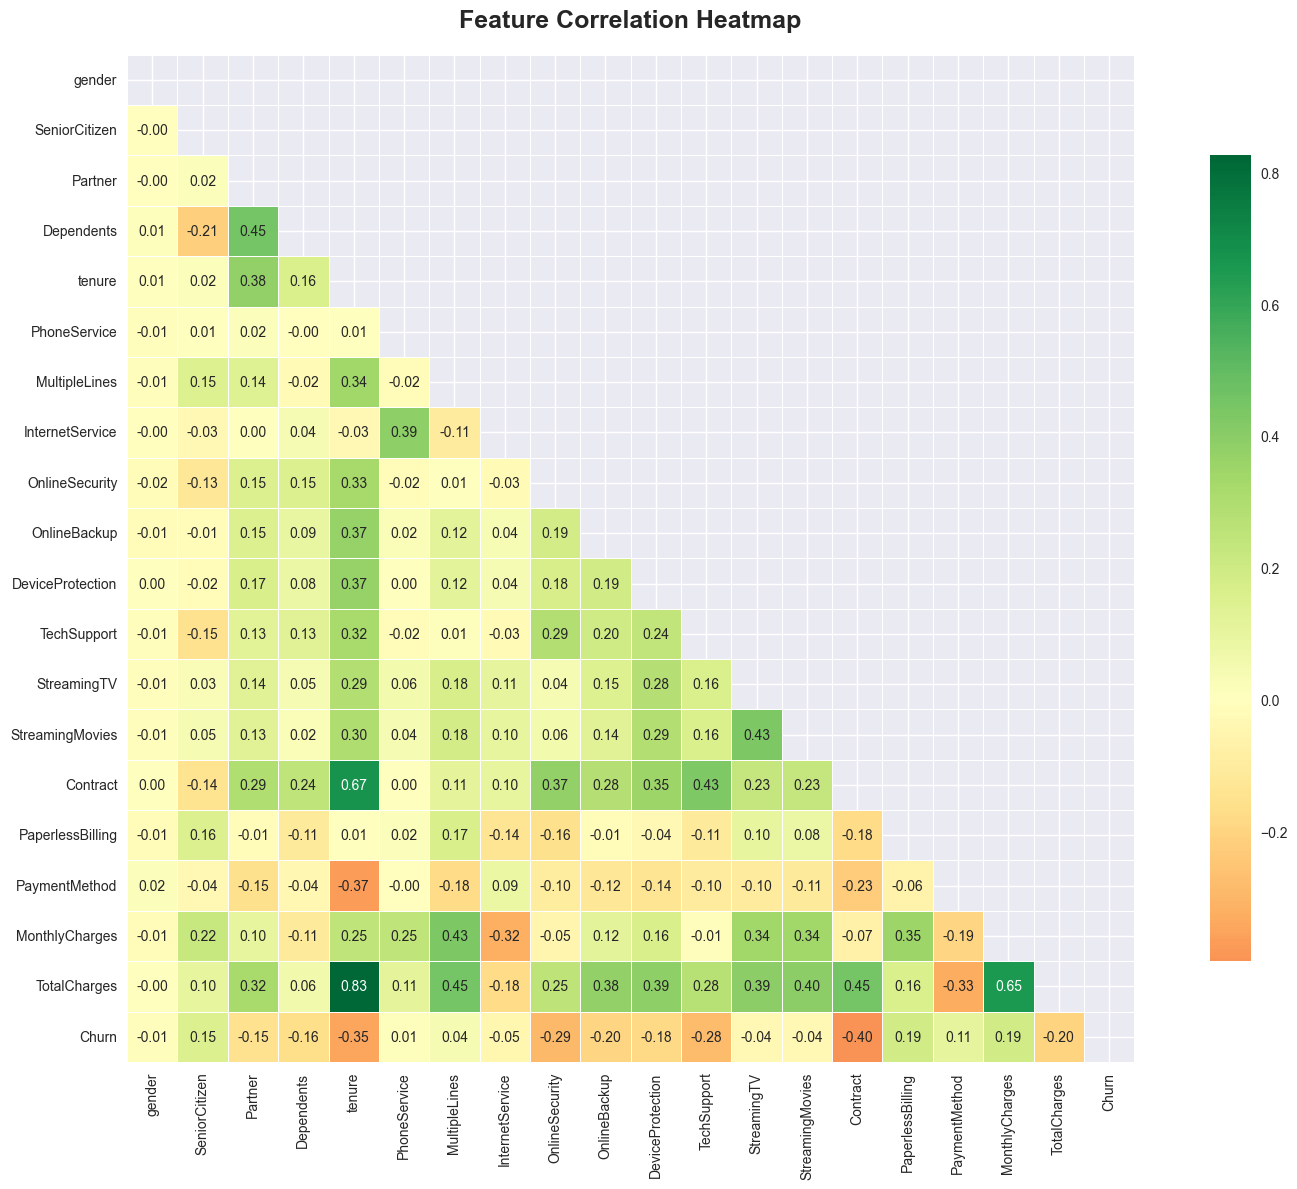

✅ Plot saved!


In [8]:
# PLOT 6: Correlation Heatmap
df_encoded = pd.read_csv('../data/cleaned_data.csv')

fig, ax = plt.subplots(figsize=(16, 12))

corr_matrix = df_encoded.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            ax=ax,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

ax.set_title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../src/images/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

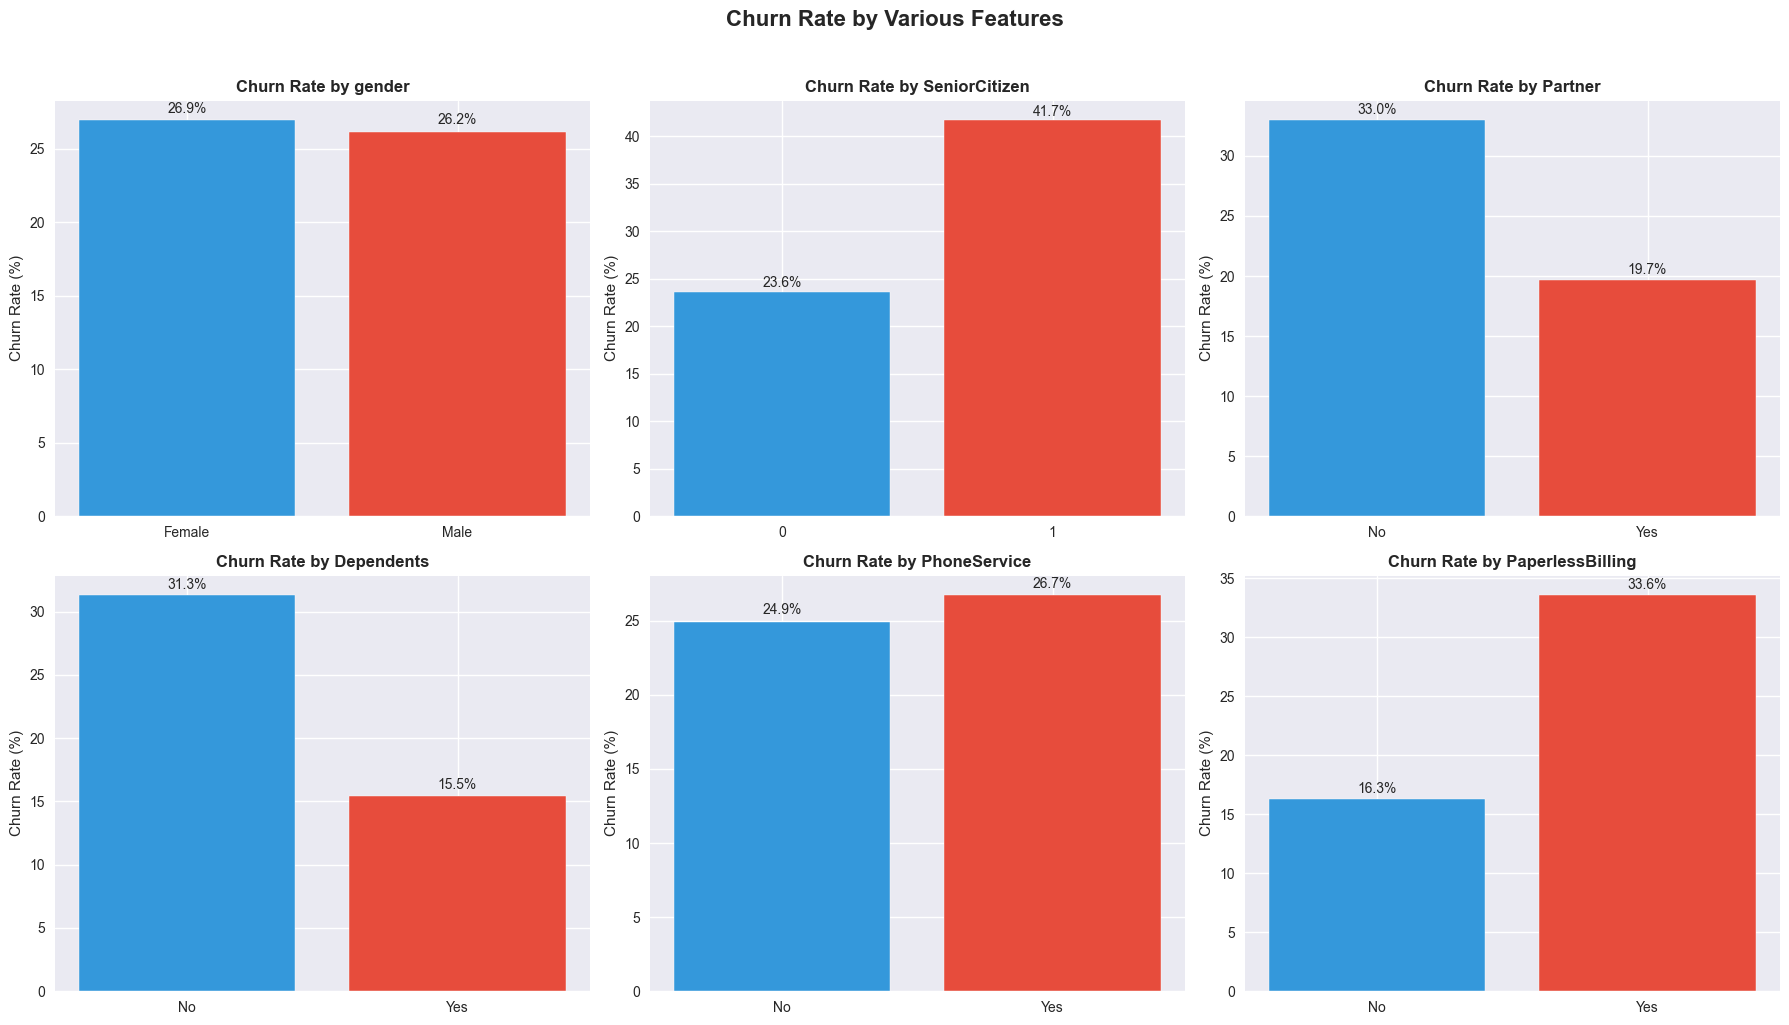

✅ Plot saved!


In [9]:
# PLOT 7: Multiple Features vs Churn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 
    'Dependents', 'PhoneService', 'PaperlessBilling'
]

for idx, feature in enumerate(categorical_features):
    row = idx // 3
    col = idx % 3
    
    churn_rate = df.groupby(feature)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    )
    
    axes[row, col].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=['#3498db', '#e74c3c'], edgecolor='white')
    axes[row, col].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[row, col].set_ylabel('Churn Rate (%)')
    
    for i, val in enumerate(churn_rate.values):
        axes[row, col].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn Rate by Various Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../src/images/07_features_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [10]:
# EDA SUMMARY
print("=" * 60)
print("📊 EDA SUMMARY")
print("=" * 60)

total = len(df)
churned = (df['Churn'] == 'Yes').sum()
stayed = (df['Churn'] == 'No').sum()

print(f"\nTotal Customers : {total:,}")
print(f"Churned         : {churned:,} ({churned/total*100:.1f}%)")
print(f"Stayed          : {stayed:,} ({stayed/total*100:.1f}%)")

print(f"\nAvg Monthly Charge (Churned): ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg Monthly Charge (Stayed) : ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

print(f"\nAvg Tenure (Churned): {df[df['Churn']=='Yes']['tenure'].mean():.0f} months")
print(f"Avg Tenure (Stayed) : {df[df['Churn']=='No']['tenure'].mean():.0f} months")

print("\n📌 Key Findings:")
print("  1. Month-to-month contracts have 42%+ churn rate")
print("  2. New customers (0-12 months) churn the most")
print("  3. Fiber optic customers churn more than DSL")
print("  4. Higher monthly charges = higher churn")
print("  5. Customers without tech support churn more")

print("\n✅ Notebook 2 Complete! Move to Notebook 3: Model Training")

📊 EDA SUMMARY

Total Customers : 7,043
Churned         : 1,869 (26.5%)
Stayed          : 5,174 (73.5%)

Avg Monthly Charge (Churned): $74.44
Avg Monthly Charge (Stayed) : $61.27

Avg Tenure (Churned): 18 months
Avg Tenure (Stayed) : 38 months

📌 Key Findings:
  1. Month-to-month contracts have 42%+ churn rate
  2. New customers (0-12 months) churn the most
  3. Fiber optic customers churn more than DSL
  4. Higher monthly charges = higher churn
  5. Customers without tech support churn more

✅ Notebook 2 Complete! Move to Notebook 3: Model Training
